### Ouverture des fichiers et jointures 

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from pathlib import Path
from fonction import *
import seaborn as sns
import numpy as np



In [2]:
### Importation des données ###


# Données communes
fp = Path("data") / "raw" / "communes" / "ADE_4-0_GPKG_WGS84G_FRA-ED2025-11-20.gpkg"
if not fp.exists():
	raise FileNotFoundError(f"File not found: {fp.resolve()}")
communes = gpd.read_file(fp, layer='commune')

# Données SWI quotidien regroupées en SWI mensuel
fp = Path("data") / "intermediate" / "datagouv" / "swimonthly_combined_1958to2025.gpkg"
if not fp.exists():
	raise FileNotFoundError(f"File not found: {fp.resolve()}")
swi_monthly = gpd.read_file(fp)

# Données SWI uniforme
fp = Path("data") / "intermediate" / "meteo_france" / "meteo_france_combined.gpkg"
if not fp.exists():
    raise FileNotFoundError(f"File not found: {fp.resolve()}")
meteo_france = gpd.read_file(fp)

# Données d'argile
fp = Path("data") / "intermediate" / "argile" / "argile.gpkg"
if not fp.exists():
    raise FileNotFoundError(f"File not found: {fp.resolve()}")
argile = gpd.read_file(fp)

In [3]:
### Affichage des données de communes ###


display(communes.head())

,cleabs,nom_officiel,nom_officiel_en_majuscules,statut,code_insee,population,date_du_recensement,organisme_recenseur,code_insee_du_canton,code_insee_de_l_arrondissement,code_insee_du_departement,code_insee_de_la_region,codes_siren_des_epci,code_siren,code_postal,superficie_cadastrale,geometry
0,COMMUNE_0000000000001001,L'Abergement-Clémenciat,L'ABERGEMENT-CLEMENCIAT,Commune simple,01001,859,2022-01-01,INSEE,0108,012,01,84,200069193,210100012,01400,1590,"MULTIPOLYGON (((4.95841 46.15327, 4.95812 46.1..."
1,COMMUNE_0000000000001002,L'Abergement-de-Varey,L'ABERGEMENT-DE-VAREY,Commune simple,01002,273,2022-01-01,INSEE,0101,011,01,84,240100883,210100020,01640,920,"MULTIPOLYGON (((5.4302 45.98277, 5.43012 45.98..."
2,COMMUNE_0000000000001004,Ambérieu-en-Bugey,AMBERIEU-EN-BUGEY,Commune simple,01004,15554,2022-01-01,INSEE,0101,011,01,84,240100883,210100046,01500,2460,"MULTIPOLYGON (((5.40882 45.94206, 5.4085 45.94..."
3,COMMUNE_0000000000001005,Ambérieux-en-Dombes,AMBERIEUX-EN-DOMBES,Commune simple,01005,1917,2022-01-01,INSEE,0122,012,01,84,200042497,210100053,01330,1590,"MULTIPOLYGON (((4.94298 45.97962, 4.94257 45.9..."
4,COMMUNE_0000000000001006,Ambléon,AMBLEON,Commune simple,01006,114,2022-01-01,INSEE,0104,011,01,84,200040350,210100061,01300,590,"MULTIPOLYGON (((5.57083 45.75338, 5.57219 45.7..."


In [4]:
### Modification de la date sur les données SWI mensuel ###


# Modification de la date pour le premier du mois
swi_monthly['DATE'] = pd.to_datetime(swi_monthly['DATE']) - pd.offsets.MonthBegin(1)

# Filtrage des données à partir de 1960
swi_monthly = swi_monthly[swi_monthly['DATE'] >= '1960-01-01']

# Affichage de la base
display(swi_monthly)

,DATE,LAMBX,LAMBY,PRENEI,PRELIQ,T,FF,Q,DLI,SSI,...,HTEURNEIGE,HTEURNEIGE6,HTEURNEIGEX,SNOW_FRAC,ECOULEMENT,WG_RACINE,WGI_RACINE,TINF_H,TSUP_H,geometry
168164,1960-01-01,600,24010,5.5,98.9,7.396774,5.145161,5.581742,87057.7,8987.6,...,0.000355,0.0,0.035,0.006452,5.3,0.319419,0.000065,-2.1,13.3,POINT (60000 2401000)
168165,1960-01-01,760,23610,0.6,91.8,7.477419,6.616129,5.709613,86828.0,9751.3,...,0.000000,0.0,0.001,0.000000,0.6,0.263484,0.000194,-1.5,12.6,POINT (76000 2361000)
168166,1960-01-01,760,23930,0.3,91.5,7.583871,6.558065,5.743839,87214.9,9749.5,...,0.000000,0.0,0.001,0.000000,0.4,0.318710,0.000129,-1.4,12.9,POINT (76000 2393000)
168167,1960-01-01,760,24010,5.9,101.1,7.064516,5.238710,5.480290,85955.7,8996.8,...,0.000355,0.0,0.030,0.012903,5.7,0.321290,0.000323,-2.2,12.6,POINT (76000 2401000)
168168,1960-01-01,760,24090,5.8,100.3,7.196774,5.203226,5.517258,86361.2,8993.0,...,0.000290,0.0,0.027,0.012903,5.6,0.321452,0.000323,-2.1,12.8,POINT (76000 2409000)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7982859,2025-10-01,11960,17050,0.0,44.5,18.122581,2.538710,8.597774,91740.2,33351.6,...,0.000000,0.0,0.000,0.000000,0.0,0.190774,0.000000,12.5,25.8,POINT (1196000 1705000)
7982860,2025-10-01,11960,17130,0.0,27.8,16.987097,2.683871,7.945290,92372.0,33203.6,...,0.000000,0.0,0.000,0.000000,0.0,0.194065,0.000000,9.3,25.8,POINT (1196000 1713000)
7982861,2025-10-01,11960,17210,0.0,27.8,16.967742,2.683871,7.937194,92353.8,33201.1,...,0.000000,0.0,0.000,0.000000,0.0,0.186806,0.000000,9.3,25.8,POINT (1196000 1721000)
7982862,2025-10-01,11960,17290,0.0,27.8,16.967742,2.683871,7.937194,92353.8,33201.1,...,0.000000,0.0,0.000,0.000000,0.0,0.204161,0.000000,9.3,25.8,POINT (1196000 1729000)


In [5]:
### Conversion des données SWI uniforme en float ###

# Conversion
meteo_france['SWI_UNIF_MENS'] = meteo_france['SWI_UNIF_MENS'].str.replace(',', '.').astype(np.float64)

# Affichage de la base
display(meteo_france)

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,geometry
0,2,641374,7106309,1960-01-01,0.863,POINT (641374 7106309)
1,2,641374,7106309,1960-02-01,0.876,POINT (641374 7106309)
2,2,641374,7106309,1960-03-01,0.856,POINT (641374 7106309)
3,2,641374,7106309,1960-04-01,0.757,POINT (641374 7106309)
4,2,641374,7106309,1960-05-01,0.673,POINT (641374 7106309)
...,...,...,...,...,...,...
7005175,9892,1215772,6046242,2024-08-01,-0.019,POINT (1215772 6046242)
7005176,9892,1215772,6046242,2024-09-01,0.007,POINT (1215772 6046242)
7005177,9892,1215772,6046242,2024-10-01,0.170,POINT (1215772 6046242)
7005178,9892,1215772,6046242,2024-11-01,0.126,POINT (1215772 6046242)


In [6]:
### Harmonisation des systèmes de coordonnées entre l'argile et le SWI mensuel ###


# Affichage du système de coordonnées de la base argile
print(argile.crs)

# Isolement des variables d'intérêt dans la base argile
cols_argile = ["geometry", "ALEA", "NIVEAU", "DPT"]

# Conversion du système de coordonnées de la base argile pour qu'il corresponde à celui des données SWI mensuel
argile=argile.to_crs(swi_monthly.crs)

EPSG:3857


In [7]:
### Harmonisation des systèmes de coordonnées entre le SWI uniforme et le SWI mensuel ###

# Affichage du système de coordonnées de la base SWI uniforme
print(meteo_france.crs)

# Isolement des variables d'intérêt dans la base SWI uniforme
cols_meteo = ["DATE", "SWI_UNIF_MENS"]

# Conversion du système de coordonnées de la base SWI uniforme pour qu'il corresponde à celui des données SWI mensuel
meteo_france=meteo_france.to_crs(swi_monthly.crs)

# Vérification des systèmes de coordonnées
print(swi_monthly.crs)
print(meteo_france.crs)

EPSG:2154
EPSG:27572
EPSG:27572


In [8]:
### Affichage des données de SWI mensuel ###


swi_monthly

,DATE,LAMBX,LAMBY,PRENEI,PRELIQ,T,FF,Q,DLI,SSI,...,HTEURNEIGE,HTEURNEIGE6,HTEURNEIGEX,SNOW_FRAC,ECOULEMENT,WG_RACINE,WGI_RACINE,TINF_H,TSUP_H,geometry
168164,1960-01-01,600,24010,5.5,98.9,7.396774,5.145161,5.581742,87057.7,8987.6,...,0.000355,0.0,0.035,0.006452,5.3,0.319419,0.000065,-2.1,13.3,POINT (60000 2401000)
168165,1960-01-01,760,23610,0.6,91.8,7.477419,6.616129,5.709613,86828.0,9751.3,...,0.000000,0.0,0.001,0.000000,0.6,0.263484,0.000194,-1.5,12.6,POINT (76000 2361000)
168166,1960-01-01,760,23930,0.3,91.5,7.583871,6.558065,5.743839,87214.9,9749.5,...,0.000000,0.0,0.001,0.000000,0.4,0.318710,0.000129,-1.4,12.9,POINT (76000 2393000)
168167,1960-01-01,760,24010,5.9,101.1,7.064516,5.238710,5.480290,85955.7,8996.8,...,0.000355,0.0,0.030,0.012903,5.7,0.321290,0.000323,-2.2,12.6,POINT (76000 2401000)
168168,1960-01-01,760,24090,5.8,100.3,7.196774,5.203226,5.517258,86361.2,8993.0,...,0.000290,0.0,0.027,0.012903,5.6,0.321452,0.000323,-2.1,12.8,POINT (76000 2409000)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7982859,2025-10-01,11960,17050,0.0,44.5,18.122581,2.538710,8.597774,91740.2,33351.6,...,0.000000,0.0,0.000,0.000000,0.0,0.190774,0.000000,12.5,25.8,POINT (1196000 1705000)
7982860,2025-10-01,11960,17130,0.0,27.8,16.987097,2.683871,7.945290,92372.0,33203.6,...,0.000000,0.0,0.000,0.000000,0.0,0.194065,0.000000,9.3,25.8,POINT (1196000 1713000)
7982861,2025-10-01,11960,17210,0.0,27.8,16.967742,2.683871,7.937194,92353.8,33201.1,...,0.000000,0.0,0.000,0.000000,0.0,0.186806,0.000000,9.3,25.8,POINT (1196000 1721000)
7982862,2025-10-01,11960,17290,0.0,27.8,16.967742,2.683871,7.937194,92353.8,33201.1,...,0.000000,0.0,0.000,0.000000,0.0,0.204161,0.000000,9.3,25.8,POINT (1196000 1729000)


In [9]:
### Affichage des données de SWI uniforme ###


meteo_france

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,geometry
0,2,641374,7106309,1960-01-01,0.863,POINT (588001.454 2673000.704)
1,2,641374,7106309,1960-02-01,0.876,POINT (588001.454 2673000.704)
2,2,641374,7106309,1960-03-01,0.856,POINT (588001.454 2673000.704)
3,2,641374,7106309,1960-04-01,0.757,POINT (588001.454 2673000.704)
4,2,641374,7106309,1960-05-01,0.673,POINT (588001.454 2673000.704)
...,...,...,...,...,...,...
7005175,9892,1215772,6046242,2024-08-01,-0.019,POINT (1171999.296 1617001.255)
7005176,9892,1215772,6046242,2024-09-01,0.007,POINT (1171999.296 1617001.255)
7005177,9892,1215772,6046242,2024-10-01,0.170,POINT (1171999.296 1617001.255)
7005178,9892,1215772,6046242,2024-11-01,0.126,POINT (1171999.296 1617001.255)


### Jointure des bases


### Explication de la jointure

La jointure effectuée dans la cellule ci-dessous combine les données météorologiques de `meteo_france` avec les données de l'indice SWI (Soil Wetness Index) de `swi_monthly`. Voici les étapes principales de cette jointure :

1. **Groupement par date** :
    - Les données de `meteo_france` sont regroupées par la colonne `DATE`. Cela permet de traiter les données pour chaque mois séparément.

2. **Filtrage des données SWI** :
    - Pour chaque date, les données correspondantes dans `swi_monthly` sont filtrées pour ne conserver que celles ayant la même date que le groupe courant de `meteo_france`.

3. **Jointure spatiale** :
    - Une jointure spatiale est réalisée entre les données météorologiques (`meteo_d`) et les données SWI filtrées (`swi_d`) en utilisant la méthode `sjoin_nearest` de GeoPandas.
    - Cette méthode associe chaque point de `meteo_d` au point le plus proche dans `swi_d`, en fonction de leur distance géographique.
    - Une distance maximale (`max_distance=100`) est définie pour limiter l'association à des points proches (à ajuster selon la résolution des données).

4. **Concaténation des résultats** :
    - Les résultats de chaque jointure (par date) sont concaténés pour former un GeoDataFrame final, `gdf_join`.

5. **Nettoyage des colonnes** :
    - Les colonnes inutiles issues de la jointure, comme `LAMBX_right`, `LAMBY_right`, `geometry_right`, et `index_right`, sont supprimées.
    - Les colonnes restantes sont renommées pour éviter les doublons et clarifier les données.

6. **Export des données** :
    - Le GeoDataFrame final est sauvegardé dans un fichier GeoPackage (`jointure_meteo_swimonthly_full.gpkg`) pour une utilisation ultérieure.

Cette jointure permet de combiner les informations météorologiques et les indices SWI pour chaque point géographique, facilitant ainsi l'analyse des relations entre les conditions météorologiques et l'humidité des sols.
```

In [10]:
### Jointure des bases meteo_france et swi_monthly ###


# Chemin de destination de la jointure
output_fp = Path("data") / "processed" / "jointure_meteo_swimonthly_full.gpkg"
output_fp.parent.mkdir(parents=True, exist_ok=True)


# Check si la jointure existe déjà
if output_fp.exists():
    print(" Jointure déjà existante — chargement depuis le disque.")
    gdf_join = gpd.read_file(output_fp)


# Jointure
else:
    print(" Jointure inexistante — calcul de la jointure spatio-temporelle.")

    # Initialisation de la liste des résultats
    res = []

    # Jointure spatio-temporelle pour chaque date
    for d, meteo_d in meteo_france.groupby("DATE"):
        swi_d = swi_monthly[swi_monthly["DATE"] == d]
        if swi_d.empty:
            continue

        tmp = gpd.sjoin_nearest(
            meteo_d,
            swi_d.drop(columns=["DATE"]),   # évite DATE_left / DATE_right
            how="left",
            max_distance=100,               # à adapter à la maille
        )

        res.append(tmp)

    # Création du GeoDataFrame final en concaténant la liste de résultats
    gdf_join = gpd.GeoDataFrame(
        pd.concat(res, ignore_index = True),
        crs = meteo_france.crs
    )

    # Suppression des doublons (même NUMERO et DATE) en gardant la première occurrence (la plus proche)
    gdf_join = (
        gdf_join
        .sort_values("DATE")
        .drop_duplicates(subset = ["NUMERO", "DATE"], keep = "first")
    )

    # Suppression des colonnes inutiles
    cols_to_drop = [
        "LAMBX_right",
        "LAMBY_right",
        "geometry_right",
        "index_right",
    ]
    
    gdf_join = gdf_join.drop(
        columns=[c for c in cols_to_drop if c in gdf_join.columns]
    )

    # Renommage des colonnes LAMBX et LAMBY
    gdf_join = gdf_join.rename(columns={
        "LAMBX_left": "LAMBX",
        "LAMBY_left": "LAMBY"
    })

    # Sauvegarde de la jointure
    gdf_join.to_file(output_fp, driver="GPKG")
    print(f" Jointure sauvegardée : {output_fp}")


# Affichage de la jointure
display(gdf_join)

 Jointure déjà existante — chargement depuis le disque.


,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,HTEURNEIGE,HTEURNEIGE6,HTEURNEIGEX,SNOW_FRAC,ECOULEMENT,WG_RACINE,WGI_RACINE,TINF_H,TSUP_H,geometry
0,2,641374,7106309,1960-01-01,0.863,4.9,51.5,4.829032,6.822581,4.584839,...,0.001710,0.001839,0.024,0.096774,4.0,0.287032,0.002484,-7.2,11.6,POINT (588001.454 2673000.704)
1,7119,635809,6442801,1960-01-01,1.081,20.2,96.4,1.990323,2.061290,3.926677,...,0.030935,0.031323,0.174,0.177419,38.0,0.298742,0.012194,-13.1,11.7,POINT (587999.304 2008998.388)
2,7118,627817,6442868,1960-01-01,1.100,22.7,119.8,2.783871,1.996774,4.188290,...,0.032935,0.033581,0.180,0.203226,50.2,0.264548,0.012129,-12.8,12.2,POINT (579999.298 2008998.399)
3,7117,619825,6442935,1960-01-01,1.095,21.8,115.4,3.277419,2.083871,4.315355,...,0.030839,0.031226,0.170,0.180645,45.7,0.284097,0.010065,-12.2,13.0,POINT (571999.291 2008998.458)
4,7116,611833,6443002,1960-01-01,1.086,23.8,108.4,3.490323,2.174194,4.422677,...,0.032871,0.033323,0.179,0.183871,41.7,0.293774,0.008742,-11.5,13.3,POINT (563999.284 2008998.565)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7005175,3831,805955,6713138,2024-12-01,0.927,0.9,68.4,4.016129,2.809677,4.880258,...,0.000000,0.000000,0.000,0.000000,0.9,0.344613,0.000097,-3.9,12.8,POINT (756000.273 2280998.1)
7005176,3832,813948,6713070,2024-12-01,0.908,1.5,71.1,2.861290,3.348387,4.495484,...,0.000000,0.000000,0.001,0.000000,1.8,0.324968,0.000613,-5.0,11.4,POINT (763999.644 2280998.186)
7005177,3833,821942,6713002,2024-12-01,0.923,3.2,71.2,2.835484,3.409677,4.498032,...,0.000000,0.000000,0.001,0.000000,3.9,0.321000,0.000516,-4.8,11.5,POINT (772000.016 2280998.33)
7005178,3827,773980,6713410,2024-12-01,0.973,0.0,64.9,4.154839,2.825806,4.791226,...,0.000000,0.000000,0.000,0.000000,0.0,0.375032,0.000774,-2.5,13.3,POINT (723999.802 2280998.23)


In [12]:
### Affichage des données d'argile ###


argile

,ALEA,DPT,NIVEAU,geometry
0,Faible,29,1.0,"POLYGON ((48327.467 2410619.543, 48378.067 241..."
1,Faible,29,1.0,"POLYGON ((48250.28 2410635.844, 48291.446 2410..."
2,Faible,29,1.0,"POLYGON ((48883.726 2410561.982, 48882.224 241..."
3,Faible,29,1.0,"POLYGON ((48814.423 2410895.518, 48809.806 241..."
4,Faible,29,1.0,"POLYGON ((50025.768 2410812.088, 50015.999 241..."
...,...,...,...,...
1180531,Faible,202,1.0,"POLYGON ((1195311.693 1729027.041, 1195362.574..."
1180532,Faible,202,1.0,"POLYGON ((1196686.075 1723499.275, 1196682.969..."
1180533,Faible,202,1.0,"POLYGON ((1196725.172 1724402.792, 1196735.399..."
1180534,Faible,202,1.0,"POLYGON ((1196566.174 1725306.136, 1196578.161..."


In [11]:


output_fp = Path("data") / "processed" / "jointure_meteo_swi_argile_nearest.gpkg"
output_fp.parent.mkdir(parents=True, exist_ok=True)

cols_argile = ["geometry", "ALEA", "NIVEAU", "DPT"]


if output_fp.exists():
    print(" Jointure MF + SWI + Argile déjà existante — chargement.")
    gdf_join_argile = gpd.read_file(output_fp)
    

# -------------------------------------------------
# 2) Sinon → calcul
# -------------------------------------------------

else:
    print(" Calcul de la jointure MF + SWI + Argile (nearest, par année).")

    # CRS
    if argile.crs != gdf_join.crs:
        argile = argile.to_crs(gdf_join.crs)

    # Ajout colonne année (sécurité)
    gdf_join = gdf_join.copy()
    gdf_join["YEAR"] = gdf_join["DATE"].dt.year

    res = []

    for y, gdf_y in gdf_join.groupby("YEAR"):
        print(f"  → année {y}")

        tmp = gpd.sjoin_nearest(
            gdf_y,
            argile[cols_argile],
            how="left",
            distance_col="dist_to_argile"
        )

        # sécurité ex æquo
        tmp = (
            tmp
            .sort_values("dist_to_argile")
            .drop_duplicates(subset=["NUMERO", "DATE"], keep="first")
        )

        res.append(tmp)

    gdf_join_argile = gpd.GeoDataFrame(
        pd.concat(res, ignore_index=True),
        crs=gdf_join.crs
    )

    # Nettoyage
    gdf_join_argile = gdf_join_argile.drop(
        columns=[c for c in ["index_right"] if c in gdf_join_argile.columns]
    )
    gdf_join_argile.loc[gdf_join_argile['dist_to_argile'] > 1000, 'NIVEAU'] = 0   #on met 0 au-delà de 1km d'une zone argileuse
    gdf_join_argile.loc[gdf_join_argile['dist_to_argile'] > 1000, 'ALEA'] = 'Aucun'
    

    # -------------------------------------------------
    # 3) Sauvegarde
    # -------------------------------------------------
    gdf_join_argile.to_file(output_fp, driver="GPKG")
    print(f" Sauvegarde terminée : {output_fp}")

# -------------------------------------------------
# 4) Résultat
# -------------------------------------------------

display(gdf_join_argile)

 Jointure MF + SWI + Argile déjà existante — chargement.


,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,WG_RACINE,WGI_RACINE,TINF_H,TSUP_H,YEAR,ALEA,NIVEAU,DPT,dist_to_argile,geometry
0,3827,773980,6713410,1960-12-01,0.982,5.7,59.2,1.941935,3.132258,4.049000,...,0.370645,0.003516,-5.7,12.0,1960,Moyen,2.0,89,0.000000,POINT (723999.802 2280998.23)
1,3826,765986,6713478,1960-12-01,0.977,4.8,58.9,2.216129,3.254839,4.104935,...,0.351065,0.002323,-5.4,12.3,1960,Moyen,2.0,89,0.000000,POINT (715999.436 2280998.385)
2,3825,757993,6713546,1960-12-01,0.973,4.4,58.9,2.338710,3.300000,4.130161,...,0.334355,0.001806,-5.2,12.4,1960,Moyen,2.0,89,0.000000,POINT (708000.072 2280998.598)
3,3824,749999,6713614,1960-12-01,0.973,4.4,58.9,2.338710,3.300000,4.130161,...,0.324452,0.001806,-5.2,12.4,1960,Faible,1.0,89,0.000000,POINT (699999.708 2280998.852)
4,5323,717146,6609971,1960-09-01,0.449,0.0,73.6,13.356667,1.530000,8.058967,...,0.263533,0.000000,2.3,24.0,1960,Moyen,2.0,3,0.000000,POINT (667998.94 2176998.552)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7005175,7245,363949,6429068,2024-08-01,0.124,0.0,37.5,20.451613,1.880645,11.601839,...,0.144290,0.000000,9.6,37.0,2024,Aucun,0.0,33,24729.333576,POINT (315997.597 1992998.292)
7005176,7245,363949,6429068,2024-03-01,1.042,0.0,160.8,10.851613,2.603226,6.793806,...,0.222710,0.000000,2.0,22.7,2024,Aucun,0.0,33,24729.333576,POINT (315997.597 1992998.292)
7005177,7245,363949,6429068,2024-12-01,0.695,0.0,72.5,8.048387,2.909677,5.864935,...,0.206065,0.000000,0.8,16.1,2024,Aucun,0.0,33,24729.333576,POINT (315997.597 1992998.292)
7005178,7245,363949,6429068,2024-05-01,0.770,0.0,94.9,15.264516,2.796774,8.711000,...,0.191290,0.000000,9.2,27.6,2024,Aucun,0.0,33,24729.333576,POINT (315997.597 1992998.292)


### Statistiques descriptives

| Nom du champ | Descriptif                                                                                                                     | Unité   | Précision |
|--------------|-------------------------------------------------------------------------------------------------------------------------------|---------|-----------|
| DATE         | Date de la mesure                                                                                                             | AAAAMMJJ|           |
| PRENEI       | Précipitations solides, cumul quotidien ]06UTC-06UTC]                                                                        | mm      | 1/10      |
| PRELIQ       | Précipitations liquides, cumul quotidien ]06UTC-06UTC]                                                                       | mm      | 1/10      |
| T            | Température moyenne quotidienne ]00UTC-00UTC]                                                                                | °C      | 1/10      |
| FF           | Vent moyen quotidien ]00UTC-00UTC]                                                                                           | m/s     | 1/10      |
| Q            | Humidité spécifique moyenne quotidienne ]00UTC-00UTC]                                                                        | g/kg    |           |
| DLI          | Rayonnement atmosphérique, cumul quotidien ]00UTC-00UTC]                                                                     | J/cm²   |           |
| SSI          | Rayonnement visible, cumul quotidien ]00UTC-00UTC]                                                                           | J/cm²   |           |
| HU           | Humidité relative moyenne quotidienne ]00UTC-00UTC]                                                                          | %       |           |
| EVAP         | Evapotranspiration totale, cumul quotidien ]06UTC-06UTC]                                                                     | mm      | 1/10      |
| ETP          | Evapotranspiration potentielle (formule de Penman-Monteith)                                                                 | mm      | 1/10      |
| PE           | Pluies efficaces, cumul quotidien ]06UTC-06UTC]                                                                              | mm      | 1/10      |
| SWI          | Indice d'humidité des sols, moyenne quotidienne [06UTC-06UTC]                                                                | %       |           |
| SSWI_10J     | Indice de sécheresse de l’humidité des sols intégré sur 10 jours (jour J et 9 jours précédents)                             | -       |           |
| DRAINC       | Drainage, cumul quotidien ]06UTC-06UTC]                                                                                      | mm      | 1/10      |
| RUNC         | Ruissellement, cumul quotidien ]06UTC-06UTC]                                                                                | mm      | 1/10      |
| RESR_NEIGE   | Équivalent en eau du manteau neigeux, moyenne quotidienne [06UTC-06UTC]                                                      | mm      | 1/10      |
| RESR_NEIGE6  | Équivalent en eau du manteau neigeux à 06 UTC                                                                               | mm      | 1/10      |
| HTEURNEIGE   | Épaisseur du manteau neigeux, moyenne quotidienne [06UTC-06UTC]                                                              | m       |           |
| HTEURNEIGE6  | Épaisseur du manteau neigeux à 06 UTC                                                                                       | m       |           |
| HTEURNEIGEX  | Épaisseur du manteau neigeux horaire maximum au cours de la journée                                                         | m       |           |
| SNOW_FRAC    | Fraction de maille recouverte par la neige, moyenne quotidienne [06UTC-06UTC]                                               | %       |           |
| ECOULEMENT   | Écoulement à la base du manteau neigeux, cumul quotidien ]06UTC-06UTC]                                                      | mm      | 1/10      |
| WG_RACINE    | Contenu en eau liquide dans la couche racinaire à 06 UTC                                                                    | m³/m³   |           |
| WGI_RACINE   | Contenu en eau gelée dans la couche racinaire à 06 UTC                                                                      | m³/m³   |           |
| TINF_H       | Température minimale des 24 températures horaires, période ]18UTC-18UTC]                                                    | °C      | 1/10      |
| TSUP_H       | Température maximale des 24 températures horaires, période ]06UTC-06UTC]                                                    | °C      | 1/10      |
| LAMBX        | Coordonnée du point de grille en Lambert II étendu (hectomètres)                                                            | hm      |           |
| LAMBY        | Coordonnée du point de grille en Lambert II étendu (hectomètres)                                                            | hm      |           |


In [12]:
### Statistiques descriptives avec la fonction describe ###


gdf_join_argile.describe()

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,SNOW_FRAC,ECOULEMENT,WG_RACINE,WGI_RACINE,TINF_H,TSUP_H,YEAR,NIVEAU,DPT,dist_to_argile
count,7.005180e+06,7.005180e+06,7.005180e+06,7005180,7.005180e+06,7.005180e+06,7.005180e+06,7.005180e+06,7.005180e+06,7.005180e+06,...,7.005180e+06,7.005180e+06,7.005180e+06,7.005180e+06,7.005180e+06,7.005180e+06,7.005180e+06,7.005180e+06,7.005180e+06,7.005180e+06
mean,5.062152e+03,6.681970e+05,6.599673e+06,1992-06-16 02:05:32.307000,6.137139e-01,5.263857e+00,7.190963e+01,1.069087e+01,2.856835e+00,6.852953e+00,...,3.786155e-02,6.551052e+00,2.717349e-01,2.525513e-03,1.198937e+00,2.165187e+01,1.992000e+03,1.653268e+00,4.717737e+01,2.988602e+02
min,2.000000e+00,1.114670e+05,6.046242e+06,1960-01-01 00:00:00,-5.700000e-02,0.000000e+00,0.000000e+00,-1.434516e+01,2.096774e-01,1.049464e+00,...,0.000000e+00,0.000000e+00,8.140000e-02,0.000000e+00,-3.020000e+01,-6.800000e+00,1.960000e+03,0.000000e+00,1.000000e+00,0.000000e+00
25%,2.414000e+03,4.996790e+05,6.393569e+06,1976-03-24 06:00:00,3.250000e-01,0.000000e+00,3.690000e+01,5.929032e+00,2.093548e+00,4.955071e+00,...,0.000000e+00,0.000000e+00,2.385484e-01,0.000000e+00,-3.400000e+00,1.540000e+01,1.976000e+03,1.000000e+00,2.300000e+01,0.000000e+00
50%,5.241000e+03,6.636830e+05,6.616330e+06,1992-06-16 00:00:00,6.620000e-01,0.000000e+00,6.230000e+01,1.035161e+01,2.716667e+00,6.440220e+00,...,0.000000e+00,0.000000e+00,2.749643e-01,0.000000e+00,9.000000e-01,2.170000e+01,1.992000e+03,2.000000e+00,4.400000e+01,0.000000e+00
75%,7.630000e+03,8.379290e+05,6.802491e+06,2008-09-08 12:00:00,9.060000e-01,1.200000e+00,9.540000e+01,1.581935e+01,3.454839e+00,8.802000e+00,...,0.000000e+00,1.300000e+00,3.076071e-01,4.000000e-04,6.500000e+00,2.770000e+01,2.008000e+03,2.000000e+00,6.600000e+01,1.043437e+02
max,9.892000e+03,1.240867e+06,7.106309e+06,2024-12-01 00:00:00,1.542000e+00,6.777000e+02,1.107100e+03,2.837097e+01,1.282069e+01,1.603855e+01,...,1.000000e+00,1.251500e+03,4.179333e-01,2.129355e-01,2.280000e+01,4.310000e+01,2.024000e+03,3.000000e+00,2.020000e+02,2.472933e+04
std,2.917439e+03,2.203358e+05,2.397082e+05,NaN,3.272674e-01,1.991311e+01,5.021953e+01,6.147450e+00,1.054441e+00,2.309131e+00,...,1.353921e-01,2.835926e+01,4.774404e-02,1.027461e-02,6.512080e+00,7.462434e+00,1.876166e+01,8.328971e-01,3.310445e+01,1.049525e+03


In [13]:
gdf_join_argile.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 7005180 entries, 0 to 7005179
Data columns (total 37 columns):
 #   Column          Dtype         
---  ------          -----         
 0   NUMERO          int64         
 1   LAMBX           int64         
 2   LAMBY           int64         
 3   DATE            datetime64[ms]
 4   SWI_UNIF_MENS   float64       
 5   PRENEI          float64       
 6   PRELIQ          float64       
 7   T               float64       
 8   FF              float64       
 9   Q               float64       
 10  DLI             float64       
 11  SSI             float64       
 12  HU              float64       
 13  EVAP            float64       
 14  ETP             float64       
 15  PE              float64       
 16  SWI             float64       
 17  SSWI_10J        float64       
 18  DRAINC          float64       
 19  RUNC            float64       
 20  RESR_NEIGE      float64       
 21  RESR_NEIGE6     float64       
 22  HTEURNEIGE

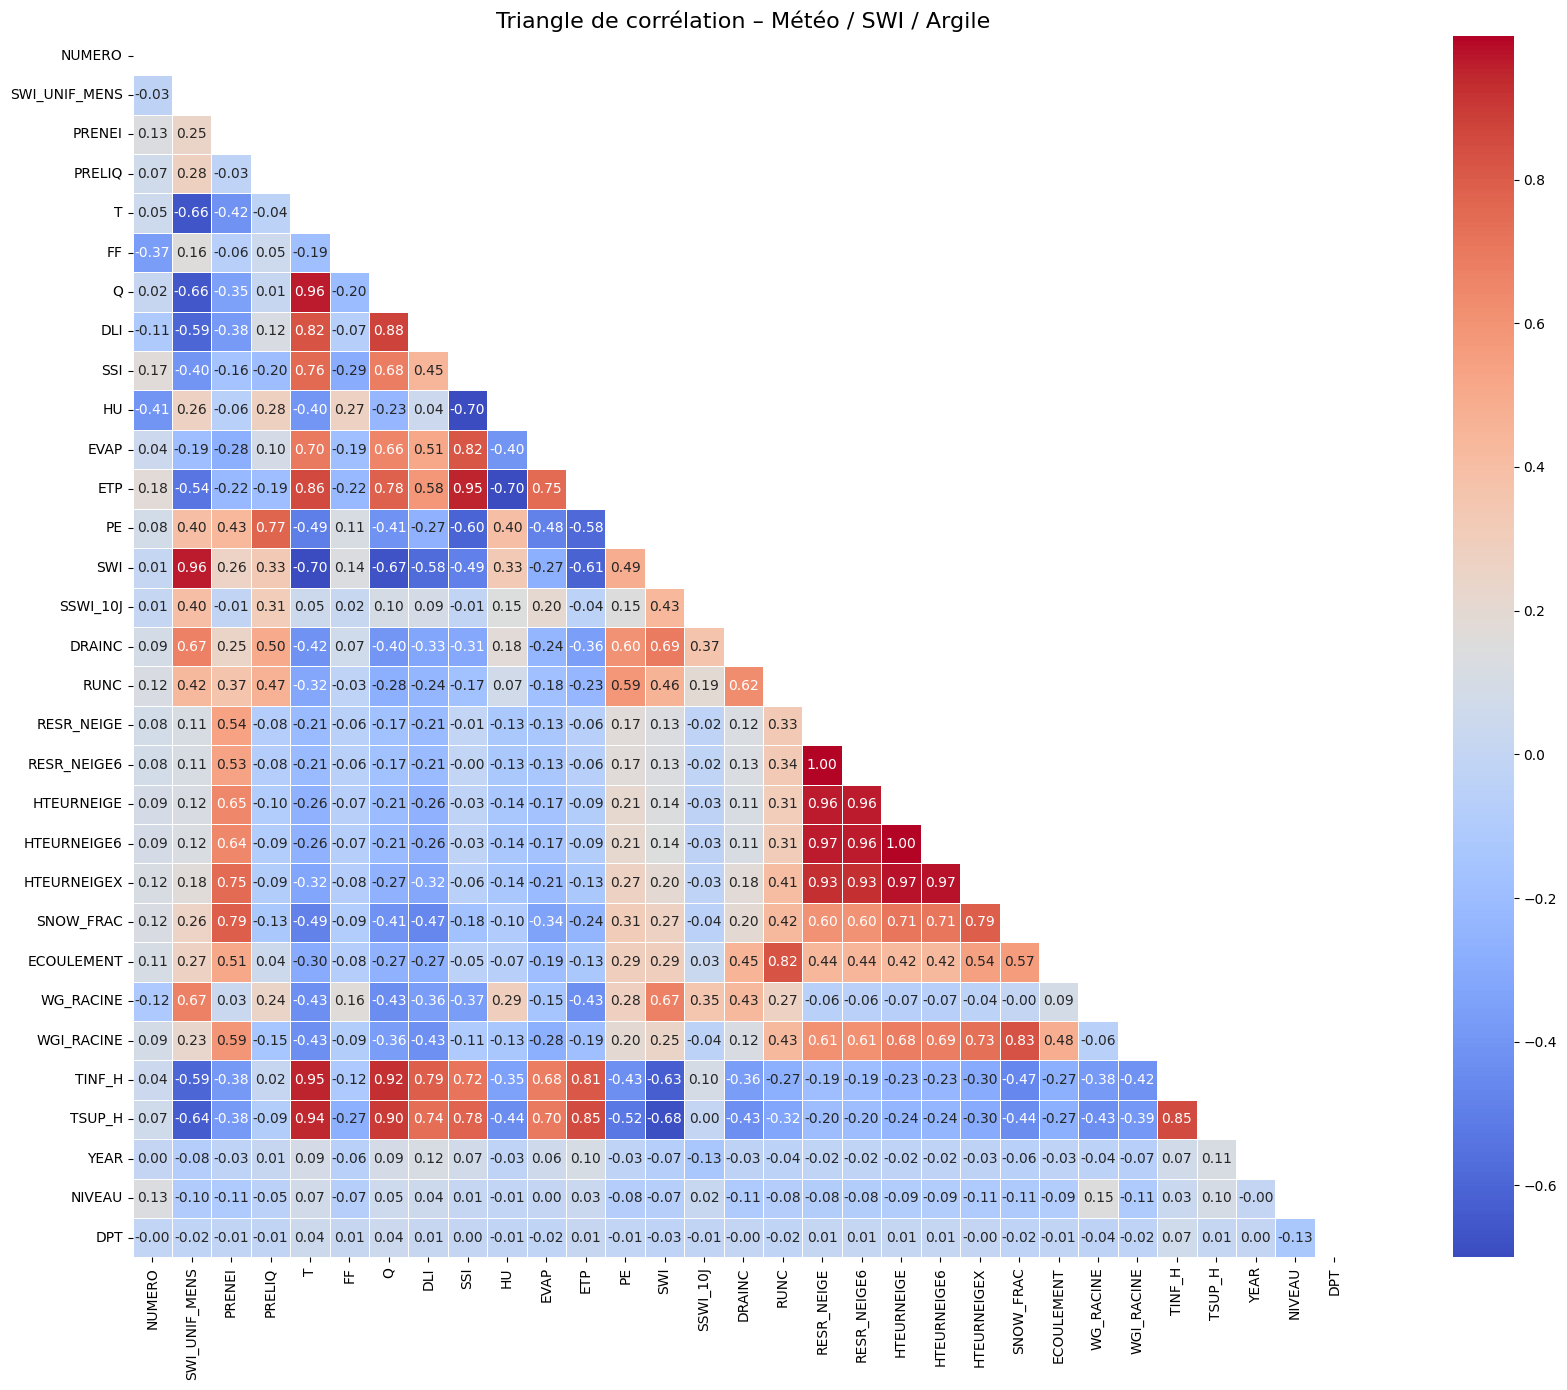

Top 10 des plus grandes corrélations avec la variable SWI :
SWI_UNIF_MENS    0.960589
T                0.695947
DRAINC           0.693557
TSUP_H           0.681959
WG_RACINE        0.670207
Q                0.668955
TINF_H           0.628107
ETP              0.607758
DLI              0.579849
SSI              0.493160
Name: SWI, dtype: float64


In [14]:
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt

numeric_cols = gdf_join_argile.select_dtypes(include=[np.number])

# Optionnel : enlever colonnes purement techniques
cols_to_exclude = ["LAMBX", "LAMBY", "dist_to_argile"]
numeric_cols = numeric_cols.drop(
    columns=[c for c in cols_to_exclude if c in numeric_cols.columns]
)


corr_matrix = numeric_cols.corr()



mask = np.triu(np.ones_like(corr_matrix, dtype=bool))



plt.figure(figsize=(20, 14))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=True,
    linewidths=0.5
)

plt.title("Triangle de corrélation – Météo / SWI / Argile", fontsize=16)
plt.tight_layout()
plt.show()

# Calculer les corrélations absolues avec la variable 'SWI'
correlations = corr_matrix['SWI'].abs().sort_values(ascending=False)

# Extraire les 10 plus grandes corrélations (en excluant 'SWI' lui-même)
top_10_correlations = correlations.drop('SWI').head(10)

# Afficher les résultats
print("Top 10 des plus grandes corrélations avec la variable SWI :")
print(top_10_correlations)

In [ ]:
gdf_join_argile['dist_to_argile'].max()

np.float64(24729.33357589963)

In [ ]:
meteo_france

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,geometry
0,2,641374,7106309,1960-01-01,0.863,POINT (588001.454 2673000.704)
1,2,641374,7106309,1960-02-01,0.876,POINT (588001.454 2673000.704)
2,2,641374,7106309,1960-03-01,0.856,POINT (588001.454 2673000.704)
3,2,641374,7106309,1960-04-01,0.757,POINT (588001.454 2673000.704)
4,2,641374,7106309,1960-05-01,0.673,POINT (588001.454 2673000.704)
...,...,...,...,...,...,...
7005175,9892,1215772,6046242,2024-08-01,-0.019,POINT (1171999.296 1617001.255)
7005176,9892,1215772,6046242,2024-09-01,0.007,POINT (1171999.296 1617001.255)
7005177,9892,1215772,6046242,2024-10-01,0.170,POINT (1171999.296 1617001.255)
7005178,9892,1215772,6046242,2024-11-01,0.126,POINT (1171999.296 1617001.255)


### Visualisation des regions étudiées 

In [ ]:
argile

,ALEA,DPT,NIVEAU,geometry
0,Faible,29,1.0,"POLYGON ((-571213.912 6183443.57, -571137.475 ..."
1,Faible,29,1.0,"POLYGON ((-571331.852 6183457.006, -571268.951..."
2,Faible,29,1.0,"POLYGON ((-570372.508 6183436.703, -570373.105..."
3,Faible,29,1.0,"POLYGON ((-570523.889 6183927.87, -570525.083 ..."
4,Faible,29,1.0,"POLYGON ((-568697.462 6183975.643, -568710.898..."
...,...,...,...,...
1180531,Faible,202,1.0,"POLYGON ((1062848.219 5208992.086, 1062904.651..."
1180532,Faible,202,1.0,"POLYGON ((1064008.211 5201385.706, 1064003.434..."
1180533,Faible,202,1.0,"POLYGON ((1064172.133 5202595.86, 1064169.147 ..."
1180534,Faible,202,1.0,"POLYGON ((1064070.615 5203830.497, 1064084.648..."


In [15]:


# Table officielle DPT -> Région (France métropolitaine)
dpt_to_region = {
    # Auvergne-Rhône-Alpes
    "01": "Auvergne-Rhône-Alpes", "03": "Auvergne-Rhône-Alpes",
    "07": "Auvergne-Rhône-Alpes", "15": "Auvergne-Rhône-Alpes",
    "26": "Auvergne-Rhône-Alpes", "38": "Auvergne-Rhône-Alpes",
    "42": "Auvergne-Rhône-Alpes", "43": "Auvergne-Rhône-Alpes",
    "63": "Auvergne-Rhône-Alpes", "69": "Auvergne-Rhône-Alpes",
    "73": "Auvergne-Rhône-Alpes", "74": "Auvergne-Rhône-Alpes",

    # Bourgogne-Franche-Comté
    "21": "Bourgogne-Franche-Comté", "25": "Bourgogne-Franche-Comté",
    "39": "Bourgogne-Franche-Comté", "58": "Bourgogne-Franche-Comté",
    "70": "Bourgogne-Franche-Comté", "71": "Bourgogne-Franche-Comté",
    "89": "Bourgogne-Franche-Comté", "90": "Bourgogne-Franche-Comté",

    # Bretagne
    "22": "Bretagne", "29": "Bretagne",
    "35": "Bretagne", "56": "Bretagne",

    # Centre-Val de Loire
    "18": "Centre-Val de Loire", "28": "Centre-Val de Loire",
    "36": "Centre-Val de Loire", "37": "Centre-Val de Loire",
    "41": "Centre-Val de Loire", "45": "Centre-Val de Loire",

    # Corse
    "2A": "Corse", "2B": "Corse",

    # Grand Est
    "08": "Grand Est", "10": "Grand Est", "51": "Grand Est",
    "52": "Grand Est", "54": "Grand Est", "55": "Grand Est",
    "57": "Grand Est", "67": "Grand Est", "68": "Grand Est",
    "88": "Grand Est",

    # Hauts-de-France
    "02": "Hauts-de-France", "59": "Hauts-de-France",
    "60": "Hauts-de-France", "62": "Hauts-de-France",
    "80": "Hauts-de-France",

    # Île-de-France
    "75": "Île-de-France", "77": "Île-de-France",
    "78": "Île-de-France", "91": "Île-de-France",
    "92": "Île-de-France", "93": "Île-de-France",
    "94": "Île-de-France", "95": "Île-de-France",

    # Normandie
    "14": "Normandie", "27": "Normandie",
    "50": "Normandie", "61": "Normandie",
    "76": "Normandie",

    # Nouvelle-Aquitaine
    "16": "Nouvelle-Aquitaine", "17": "Nouvelle-Aquitaine",
    "19": "Nouvelle-Aquitaine", "23": "Nouvelle-Aquitaine",
    "24": "Nouvelle-Aquitaine", "33": "Nouvelle-Aquitaine",
    "40": "Nouvelle-Aquitaine", "47": "Nouvelle-Aquitaine",
    "64": "Nouvelle-Aquitaine", "79": "Nouvelle-Aquitaine",
    "86": "Nouvelle-Aquitaine", "87": "Nouvelle-Aquitaine",

    # Occitanie
    "09": "Occitanie", "11": "Occitanie", "12": "Occitanie",
    "30": "Occitanie", "31": "Occitanie", "32": "Occitanie",
    "34": "Occitanie", "46": "Occitanie", "48": "Occitanie",
    "65": "Occitanie", "66": "Occitanie", "81": "Occitanie",
    "82": "Occitanie",

    # Pays de la Loire
    "44": "Pays de la Loire", "49": "Pays de la Loire",
    "53": "Pays de la Loire", "72": "Pays de la Loire",
    "85": "Pays de la Loire",

    # Provence-Alpes-Côte d’Azur
    "04": "Provence-Alpes-Côte d’Azur", "05": "Provence-Alpes-Côte d’Azur",
    "06": "Provence-Alpes-Côte d’Azur", "13": "Provence-Alpes-Côte d’Azur",
    "83": "Provence-Alpes-Côte d’Azur", "84": "Provence-Alpes-Côte d’Azur",
}

# S'assurer que DPT est bien une string à 2 caractères
argile["DPT"] = argile["DPT"].astype(str).str.zfill(2)

# Ajout de la colonne REGION
argile["REGION"] = argile["DPT"].map(dpt_to_region)

# Départements non reconnus
missing = argile[argile["REGION"].isna()]["DPT"].unique()
print("Départements non mappés :", missing)

# Comptage par région
argile["REGION"].value_counts()

Départements non mappés : ['201' '202']


REGION
Nouvelle-Aquitaine            159279
Auvergne-Rhône-Alpes          143156
Occitanie                     137484
Grand Est                     130114
Bourgogne-Franche-Comté       102098
Hauts-de-France                94831
Centre-Val de Loire            92144
Pays de la Loire               76632
Normandie                      75695
Provence-Alpes-Côte d’Azur     70034
Bretagne                       58957
Île-de-France                  32874
Name: count, dtype: int64

In [16]:
# S'assurer que DPT est bien une string à 2 caractères
gdf_join_argile["DPT"] = gdf_join_argile["DPT"].astype(str).str.zfill(2)

# Ajout de la colonne REGION
gdf_join_argile["REGION"] = gdf_join_argile["DPT"].map(dpt_to_region)

# Départements non reconnus
missing = gdf_join_argile[gdf_join_argile["REGION"].isna()]["DPT"].unique()
print("Départements non mappés :", missing)

# Comptage par région
gdf_join_argile["REGION"].value_counts()

Départements non mappés : ['202' '201']


REGION
Nouvelle-Aquitaine            1071720
Occitanie                      931320
Auvergne-Rhône-Alpes           885300
Grand Est                      742560
Bourgogne-Franche-Comté        598260
Centre-Val de Loire            478920
Provence-Alpes-Côte d’Azur     428220
Pays de la Loire               414960
Hauts-de-France                410280
Normandie                      386100
Bretagne                       379080
Île-de-France                  147420
Name: count, dtype: int64

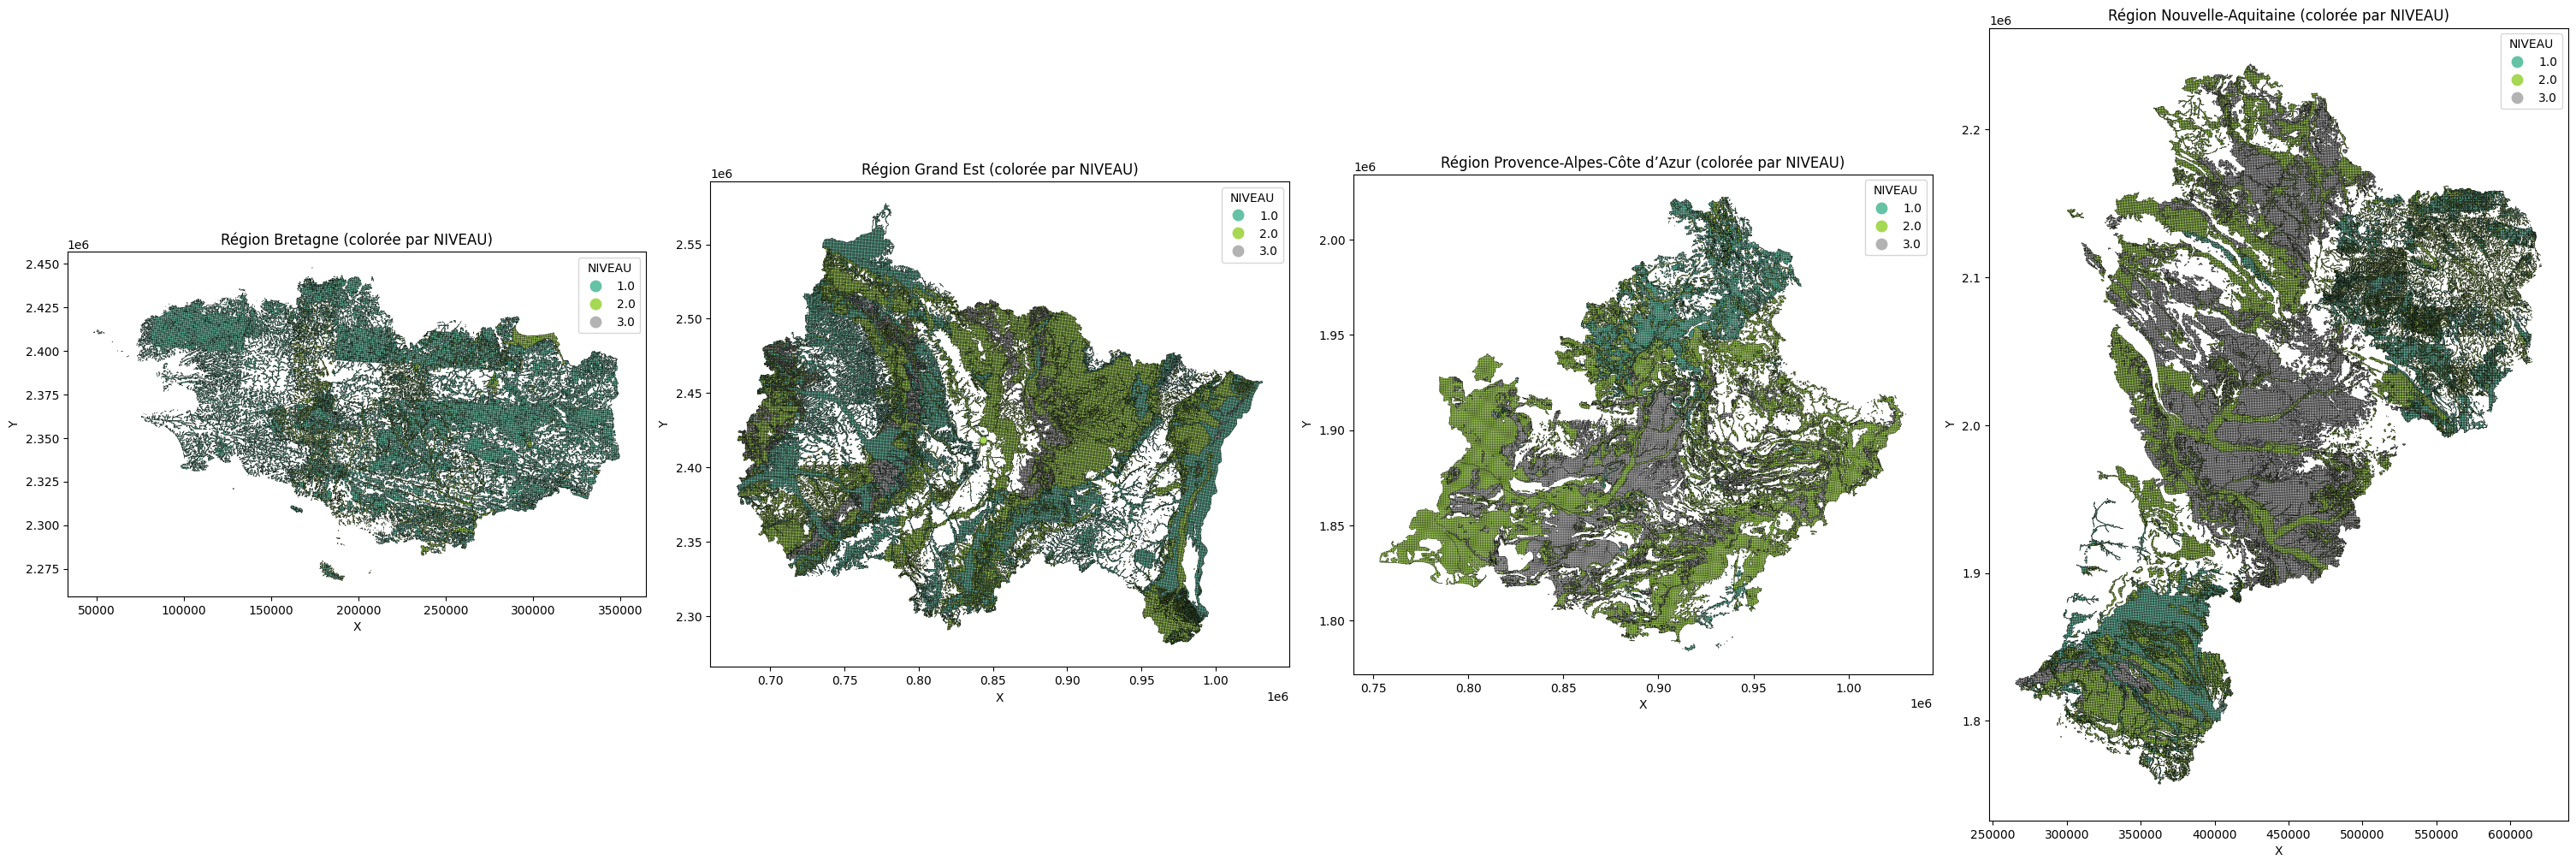

In [17]:
# Régions à afficher (basées sur la colonne REGION)
regions = [
    "Bretagne",
    "Grand Est",
    "Provence-Alpes-Côte d’Azur",
    "Nouvelle-Aquitaine"
]

# Création de la figure
fig, axes = plt.subplots(1, 4, figsize=(30, 15), constrained_layout=True)
for ax, region_name in zip(axes, regions):

    selected = argile[argile["REGION"] == region_name].copy()

    if selected.empty:
        print(f"Aucune géométrie pour la région {region_name}.")
        ax.set_title(f"{region_name} (Aucune donnée)")
        ax.axis("off")
        continue

    # Assurer NIVEAU comme variable catégorielle
    selected["NIVEAU"] = selected["NIVEAU"].astype("category")

    selected.plot(
        column="NIVEAU",
        cmap="Set2",
        legend=True,
        legend_kwds={"title": "NIVEAU"},
        ax=ax,
        edgecolor="black",
        linewidth=0.2
    )

    ax.set_title(f"Région {region_name} (colorée par NIVEAU)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

plt.show()

In [18]:
df = argile.copy()

df["REGION"] = df["REGION"].astype("category")
df["NIVEAU"] = df["NIVEAU"].astype("category")


counts = (
    df
    .groupby(["REGION", "NIVEAU"], observed=True)
    .size()
    .reset_index(name="count")
)


counts["percent"] = (
    counts["count"]
    / counts.groupby("REGION", observed=True)["count"].transform("sum")
    * 100
)

result = counts.sort_values(["REGION", "NIVEAU"])

pivot = (
    result
    .pivot(index="REGION", columns="NIVEAU", values="percent")
    .fillna(0)
    .round(2)
)

pivot.columns = [f"Argile_NIVEAU_{c}" for c in pivot.columns]

display(pivot)

,Argile_NIVEAU_1.0,Argile_NIVEAU_2.0,Argile_NIVEAU_3.0
REGION,,,
Auvergne-Rhône-Alpes,45.95,43.84,10.21
Bourgogne-Franche-Comté,33.38,64.88,1.74
Bretagne,76.22,23.57,0.21
Centre-Val de Loire,16.80,61.44,21.77
Grand Est,46.44,43.83,9.73
Hauts-de-France,49.64,40.10,10.26
Normandie,60.75,35.67,3.59
Nouvelle-Aquitaine,22.36,49.80,27.83
Occitanie,19.66,47.79,32.55


In [30]:
gdf_join_argile.crs

<Projected CRS: EPSG:27572>
Name: NTF (Paris) / Lambert zone II
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: France mainland onshore between 50.5 grads and 53.5 grads North (45°27'N to 48°09'N). Also used over all onshore mainland France.
- bounds: (-4.87, 42.33, 8.23, 51.14)
Coordinate Operation:
- name: Lambert zone II
- method: Lambert Conic Conformal (1SP)
Datum: Nouvelle Triangulation Francaise (Paris)
- Ellipsoid: Clarke 1880 (IGN)
- Prime Meridian: Paris

In [29]:
communes.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [34]:
gdf_join_argile

MemoryError: Unable to allocate 321. MiB for an array with shape (6, 7005180) and data type float64

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,WGI_RACINE,TINF_H,TSUP_H,YEAR,ALEA,NIVEAU,DPT,dist_to_argile,geometry,REGION
0,3827,773980,6713410,1960-12-01,0.982,5.7,59.2,1.941935,3.132258,4.049000,...,0.003516,-5.7,12.0,1960,Moyen,2.0,89,0.000000,POINT (723999.802 2280998.23),Bourgogne-Franche-Comté
1,3826,765986,6713478,1960-12-01,0.977,4.8,58.9,2.216129,3.254839,4.104935,...,0.002323,-5.4,12.3,1960,Moyen,2.0,89,0.000000,POINT (715999.436 2280998.385),Bourgogne-Franche-Comté
2,3825,757993,6713546,1960-12-01,0.973,4.4,58.9,2.338710,3.300000,4.130161,...,0.001806,-5.2,12.4,1960,Moyen,2.0,89,0.000000,POINT (708000.072 2280998.598),Bourgogne-Franche-Comté
3,3824,749999,6713614,1960-12-01,0.973,4.4,58.9,2.338710,3.300000,4.130161,...,0.001806,-5.2,12.4,1960,Faible,1.0,89,0.000000,POINT (699999.708 2280998.852),Bourgogne-Franche-Comté
4,5323,717146,6609971,1960-09-01,0.449,0.0,73.6,13.356667,1.530000,8.058967,...,0.000000,2.3,24.0,1960,Moyen,2.0,03,0.000000,POINT (667998.94 2176998.552),Auvergne-Rhône-Alpes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7005175,7245,363949,6429068,2024-08-01,0.124,0.0,37.5,20.451613,1.880645,11.601839,...,0.000000,9.6,37.0,2024,Aucun,0.0,33,24729.333576,POINT (315997.597 1992998.292),Nouvelle-Aquitaine
7005176,7245,363949,6429068,2024-03-01,1.042,0.0,160.8,10.851613,2.603226,6.793806,...,0.000000,2.0,22.7,2024,Aucun,0.0,33,24729.333576,POINT (315997.597 1992998.292),Nouvelle-Aquitaine
7005177,7245,363949,6429068,2024-12-01,0.695,0.0,72.5,8.048387,2.909677,5.864935,...,0.000000,0.8,16.1,2024,Aucun,0.0,33,24729.333576,POINT (315997.597 1992998.292),Nouvelle-Aquitaine
7005178,7245,363949,6429068,2024-05-01,0.770,0.0,94.9,15.264516,2.796774,8.711000,...,0.000000,9.2,27.6,2024,Aucun,0.0,33,24729.333576,POINT (315997.597 1992998.292),Nouvelle-Aquitaine


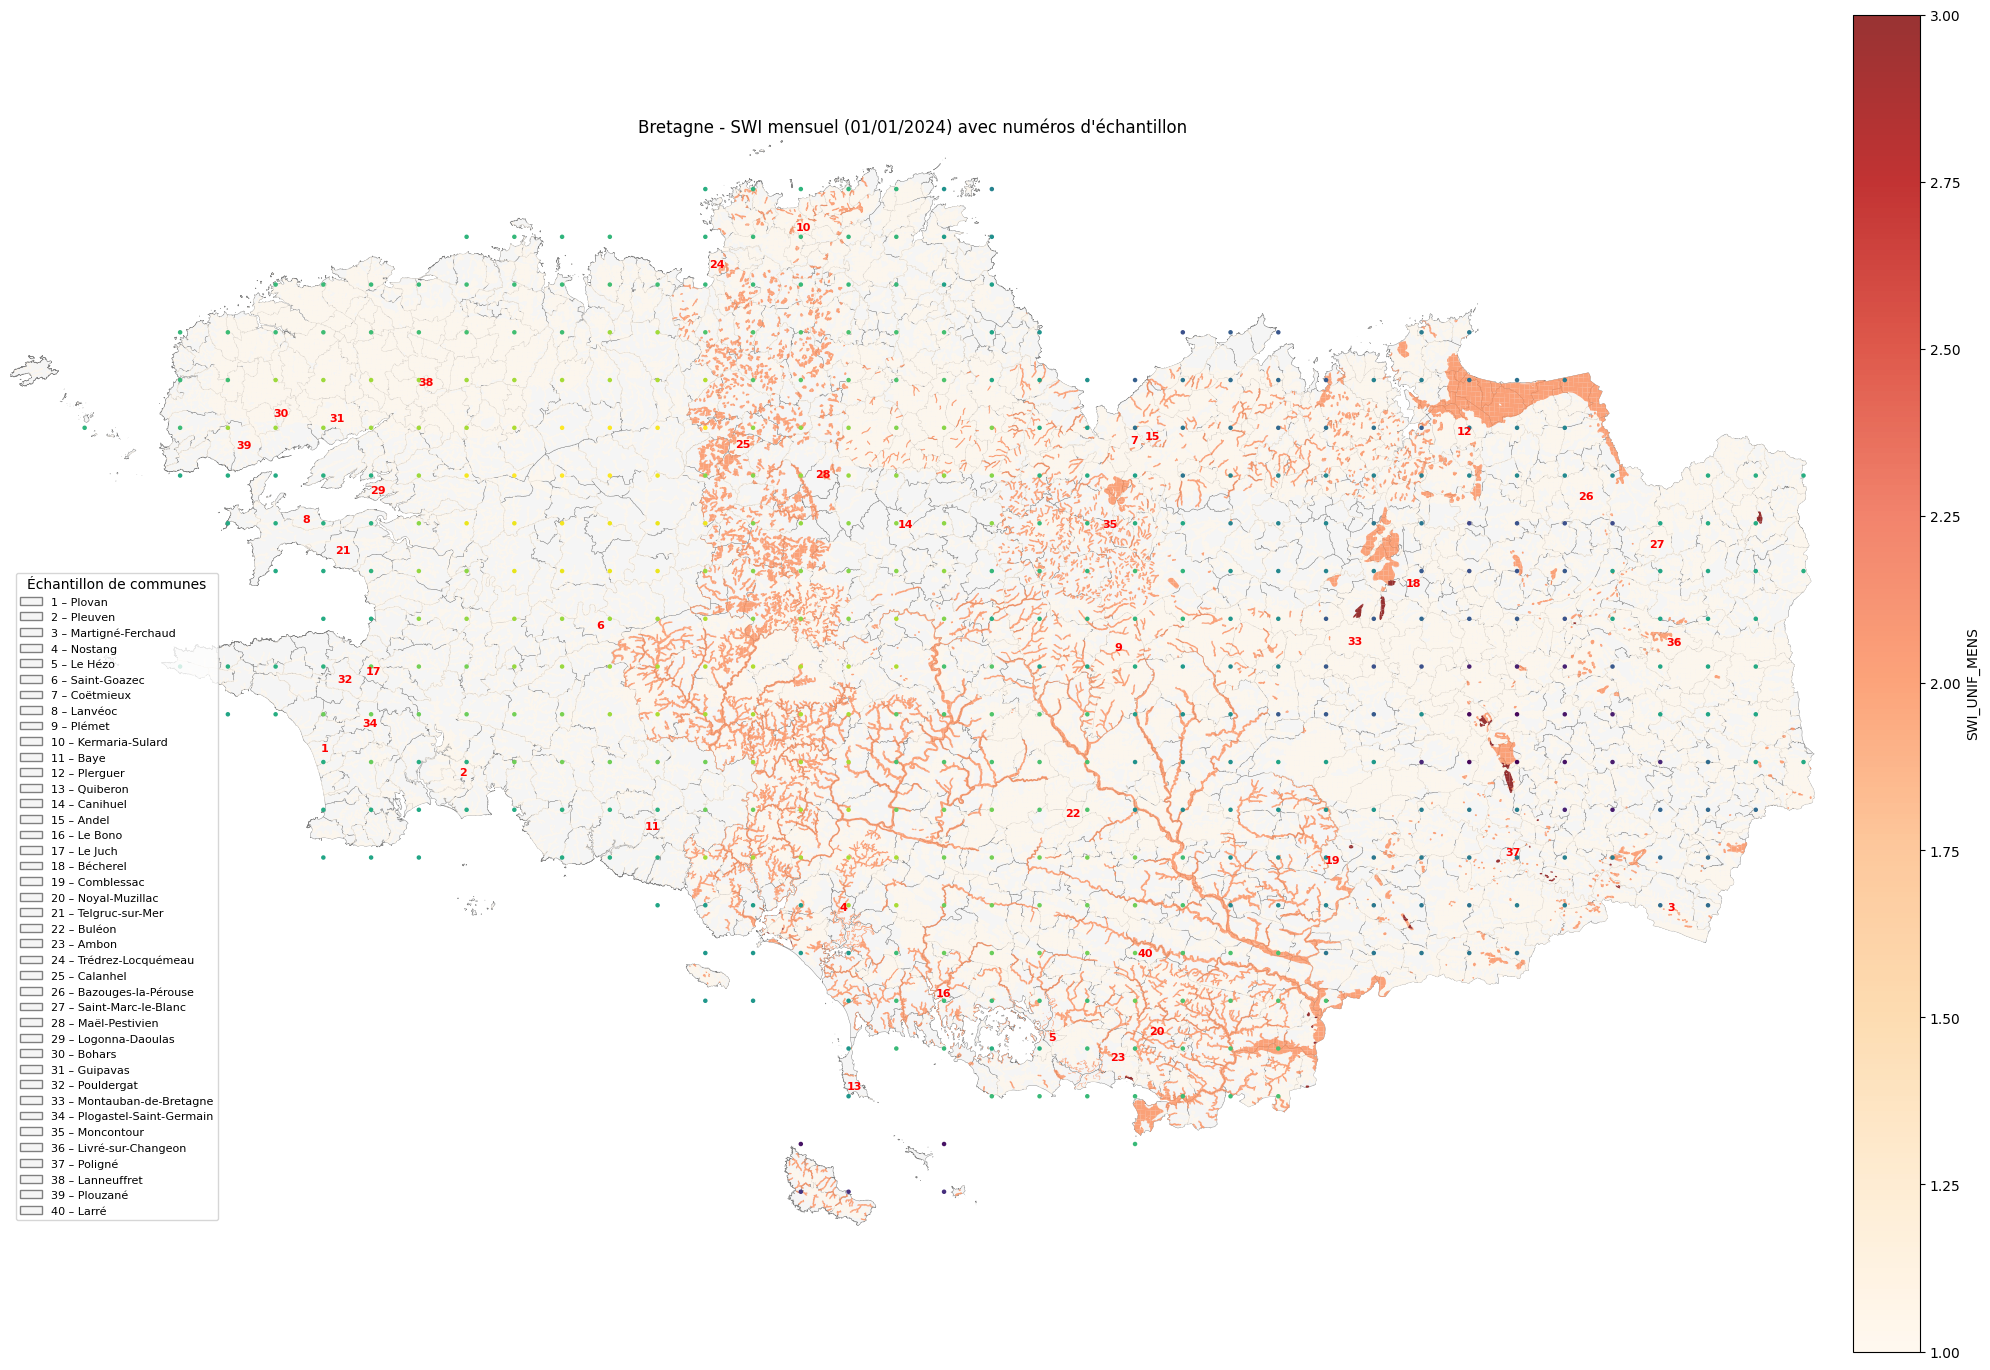

In [ ]:
import matplotlib.patches as mpatches

# Communes Bretagne dans le bon CRS
communes_bretagne = communes[
    communes["code_insee_de_la_region"] == "53"
].to_crs(gdf_join_argile.crs)

# Échantillon de communes
ech_communes = communes_bretagne.sample(40, random_state=0).copy()
ech_communes["ID_ECH"] = range(1, len(ech_communes) + 1)

bretagne_data = gdf_join_argile[
    (gdf_join_argile["REGION"] == "Bretagne") &
    (gdf_join_argile["DATE"] == "2024-01-01")
]

argile_bretagne = argile[argile["REGION"] == "Bretagne"].to_crs(gdf_join_argile.crs)


fig, ax = plt.subplots(figsize=(20, 15))


# --- Fond argile, très transparent 
argile_bretagne.plot(
    ax=ax,
    column="NIVEAU",   # ou autre champ d’argile
    cmap="OrRd",
    alpha=0.8,                 # transparence
    linewidth=0,
)

# Fond communes
communes_bretagne.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="grey",
    linewidth=0.3, 
    zorder=0
)
# Points maille
points = bretagne_data.plot(
    column="SWI_UNIF_MENS",
    ax=ax,
    cmap="viridis",
    markersize=5,
    legend=False
)

# Colorbar
cbar = plt.colorbar(points.collections[0], ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("SWI_UNIF_MENS")

# Numéros sur la carte pour l’échantillon
ech_communes["centroid"] = ech_communes.geometry.centroid
for x, y, num in zip(
    ech_communes["centroid"].x,
    ech_communes["centroid"].y,
    ech_communes["ID_ECH"]
):
    ax.text(
        x, y, str(num),
        fontsize=8,
        ha="center",
        va="center",
        color="red",
        fontweight="bold"
    )

# Légende : "n – nom_commune"
legend_patches = []
for _, row in ech_communes.iterrows():
    label = f"{row['ID_ECH']} – {row['nom_officiel']}"
    patch = mpatches.Patch(
        facecolor="whitesmoke",
        edgecolor="grey",
        label=label
    )
    legend_patches.append(patch)

ax.legend(
    handles=legend_patches,
    title="Échantillon de communes",
    loc="lower left",
    fontsize=8,
    frameon=True
)

ax.set_xlim(communes_bretagne.total_bounds[0], communes_bretagne.total_bounds[2])
ax.set_ylim(communes_bretagne.total_bounds[1], communes_bretagne.total_bounds[3])

ax.set_title("Bretagne - SWI mensuel (01/01/2024) avec numéros d'échantillon")
ax.set_axis_off()
plt.tight_layout()
plt.show()


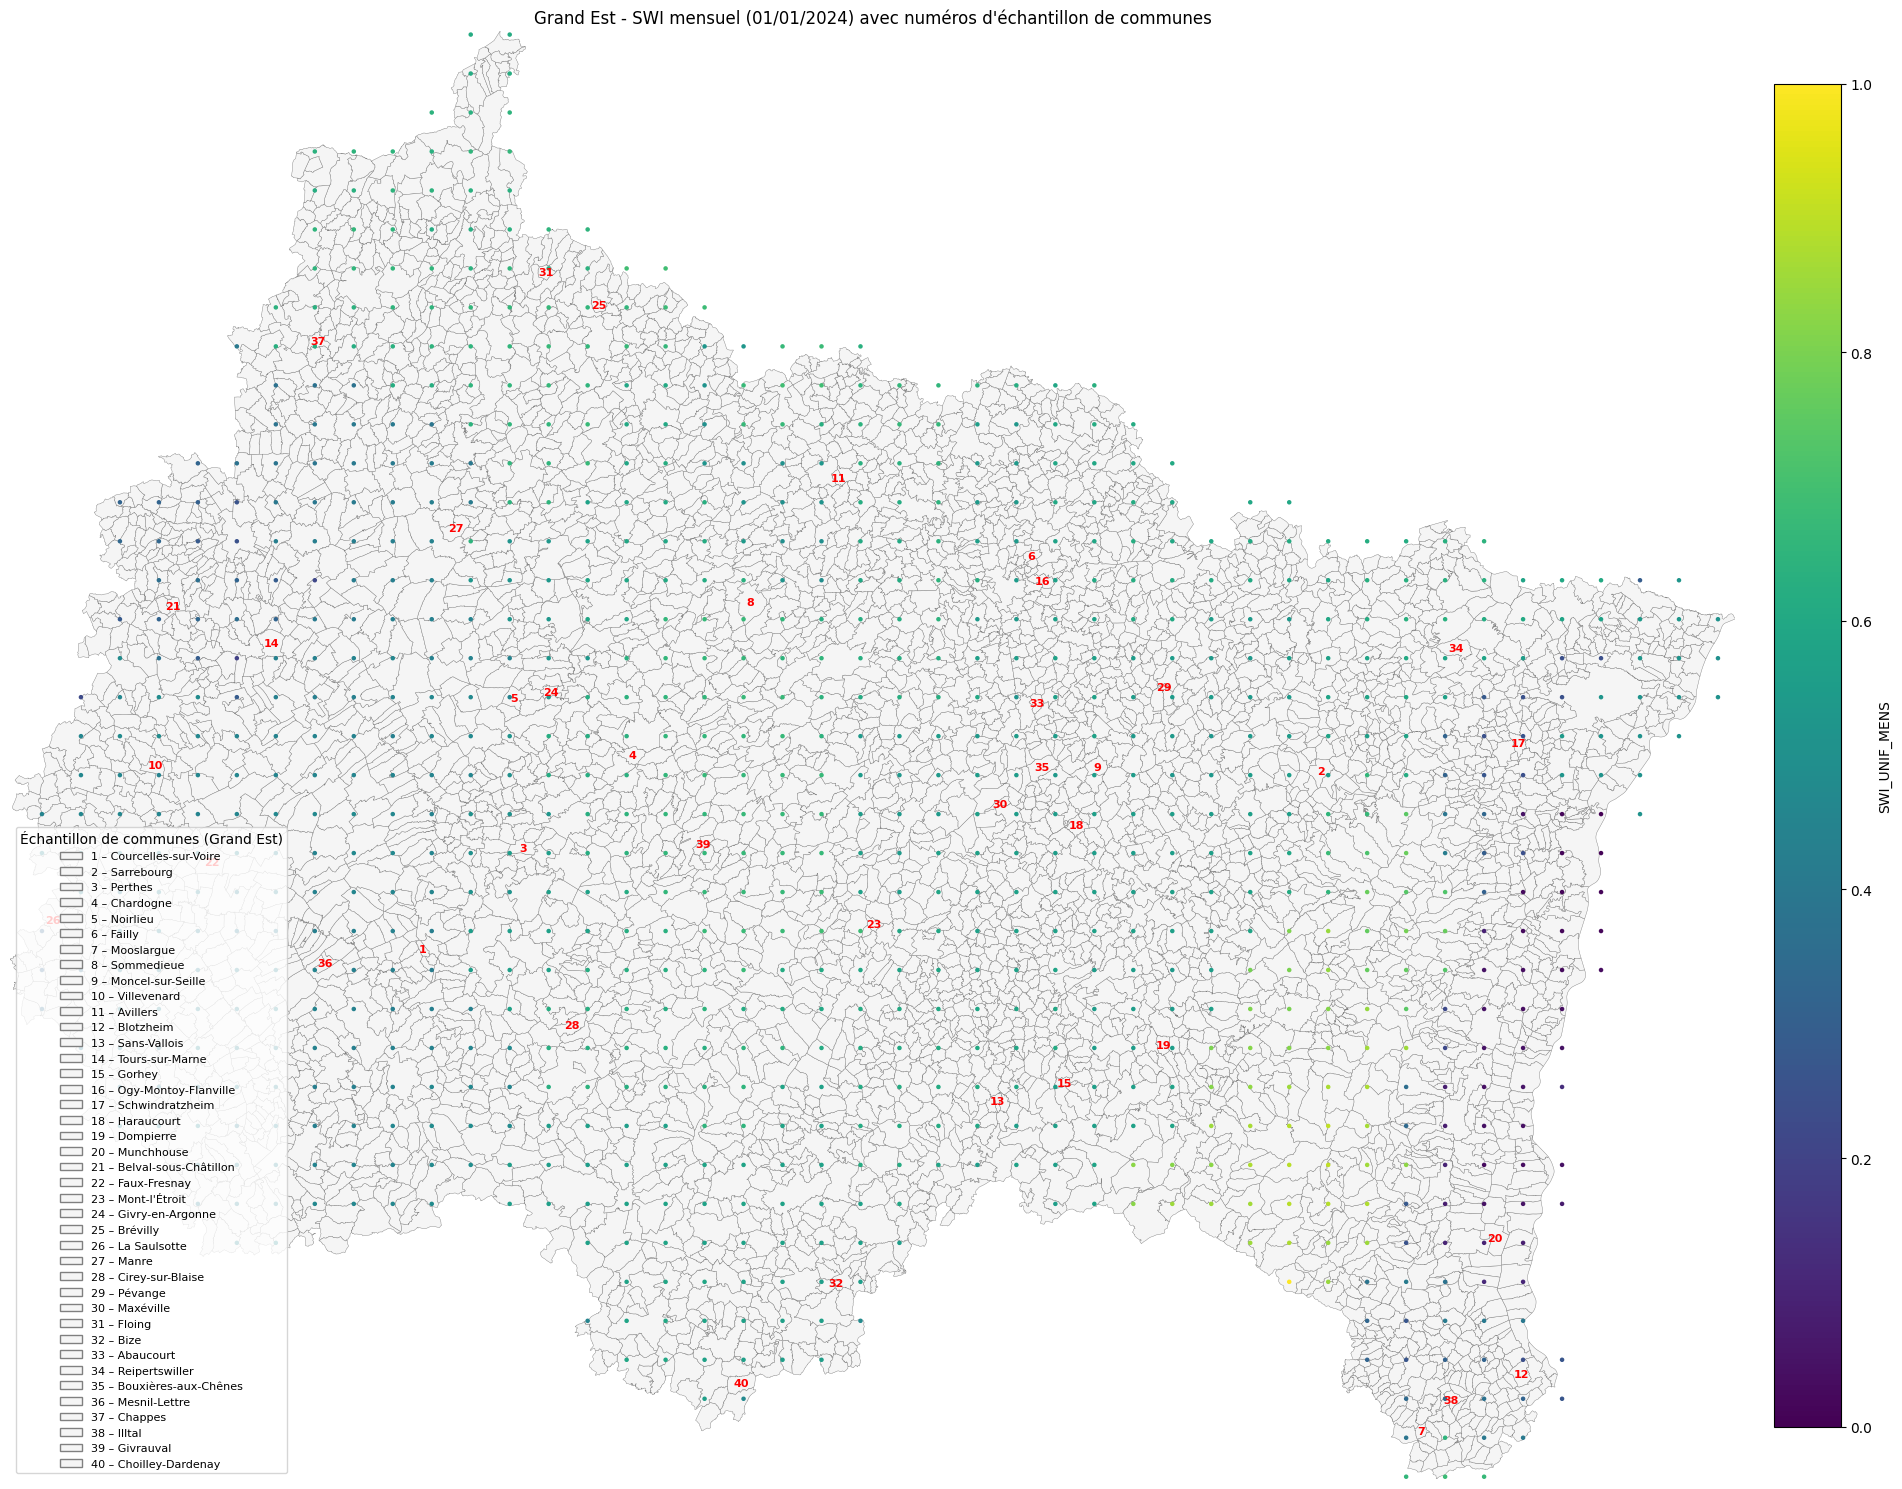

In [42]:


# Communes Grand Est dans le bon CRS
communes_grand_est = communes[
    communes["code_insee_de_la_region"] == "44"   # Grand Est
].to_crs(gdf_join_argile.crs)

# Échantillon de communes Grand Est
ech_communes_GE = communes_grand_est.sample(40, random_state=0).copy()
ech_communes_GE["ID_ECH"] = range(1, len(ech_communes_GE) + 1)

# Données maille Grand Est pour une date
grand_est_data = gdf_join_argile[
    (gdf_join_argile["REGION"] == "Grand Est") &
    (gdf_join_argile["DATE"] == "2024-01-01")
]

fig, ax = plt.subplots(figsize=(20, 15))

# Fond communes Grand Est
communes_grand_est.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="grey",
    linewidth=0.3
)

# Points maille
points = grand_est_data.plot(
    column="SWI_UNIF_MENS",
    ax=ax,
    cmap="viridis",
    markersize=5,
    legend=False
)

# Colorbar
cbar = plt.colorbar(points.collections[0], ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("SWI_UNIF_MENS")

# Numéros sur la carte pour l’échantillon
ech_communes_GE["centroid"] = ech_communes_GE.geometry.centroid
for x, y, num in zip(
    ech_communes_GE["centroid"].x,
    ech_communes_GE["centroid"].y,
    ech_communes_GE["ID_ECH"]
):
    ax.text(
        x, y, str(num),
        fontsize=8,
        ha="center",
        va="center",
        color="red",
        fontweight="bold"
    )

# Légende numéro ↔ nom de commune
legend_patches = []
for _, row in ech_communes_GE.iterrows():
    label = f"{row['ID_ECH']} – {row['nom_officiel']}"
    patch = mpatches.Patch(
        facecolor="whitesmoke",
        edgecolor="grey",
        label=label
    )
    legend_patches.append(patch)

ax.legend(
    handles=legend_patches,
    title="Échantillon de communes (Grand Est)",
    loc="lower left",
    fontsize=8,
    frameon=True
)

# Zoom sur Grand Est
ax.set_xlim(communes_grand_est.total_bounds[0], communes_grand_est.total_bounds[2])
ax.set_ylim(communes_grand_est.total_bounds[1], communes_grand_est.total_bounds[3])

ax.set_title("Grand Est - SWI mensuel (01/01/2024) avec numéros d'échantillon de communes")
ax.set_axis_off()
plt.tight_layout()
plt.show()


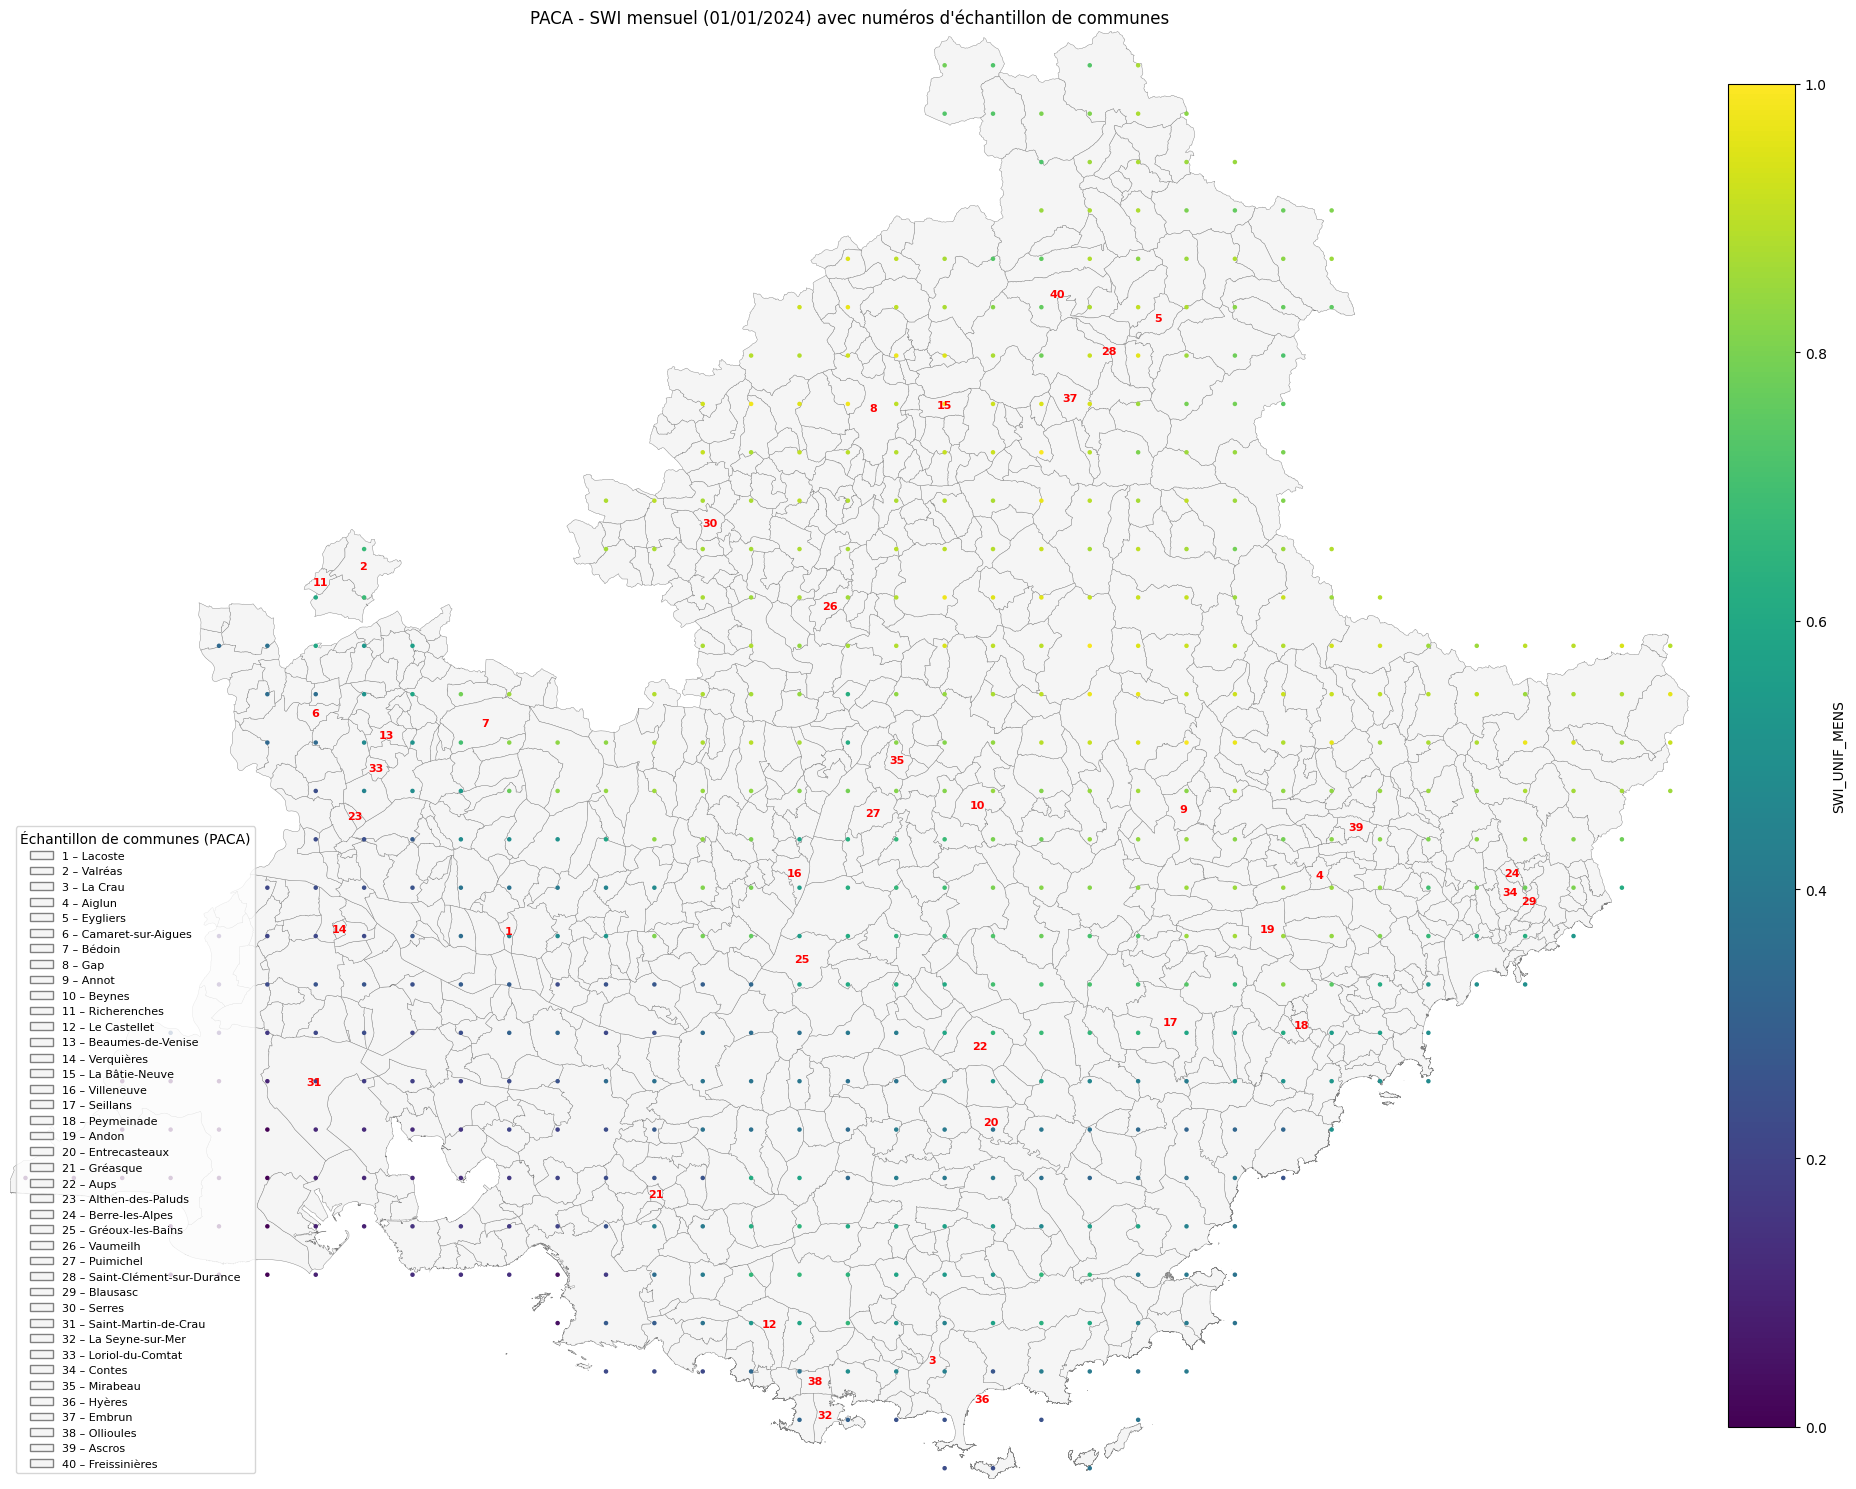

In [45]:


# Communes PACA dans le bon CRS
communes_paca = communes[
    communes["code_insee_de_la_region"] == "93"   # Provence-Alpes-Côte d'Azur
].to_crs(gdf_join_argile.crs)

# Échantillon de communes PACA
ech_communes_PACA = communes_paca.sample(40, random_state=0).copy()
ech_communes_PACA["ID_ECH"] = range(1, len(ech_communes_PACA) + 1)

# Données maille PACA pour une date donnée
paca_data = gdf_join_argile[
    (gdf_join_argile["REGION"] == "Provence-Alpes-Côte d’Azur") &
    (gdf_join_argile["DATE"] == "2024-01-01")
]

fig, ax = plt.subplots(figsize=(20, 15))

# Fond communes PACA
communes_paca.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="grey",
    linewidth=0.3
)

# Points maille SWI
points = paca_data.plot(
    column="SWI_UNIF_MENS",
    ax=ax,
    cmap="viridis",
    markersize=5,
    legend=False
)

# Colorbar
cbar = plt.colorbar(points.collections[0], ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("SWI_UNIF_MENS")

# Numéros sur la carte pour l’échantillon
ech_communes_PACA["centroid"] = ech_communes_PACA.geometry.centroid
for x, y, num in zip(
    ech_communes_PACA["centroid"].x,
    ech_communes_PACA["centroid"].y,
    ech_communes_PACA["ID_ECH"]
):
    ax.text(
        x, y, str(num),
        fontsize=8,
        ha="center",
        va="center",
        color="red",
        fontweight="bold"
    )

# Légende numéro ↔ nom de commune
legend_patches = []
for _, row in ech_communes_PACA.iterrows():
    label = f"{row['ID_ECH']} – {row['nom_officiel']}"
    patch = mpatches.Patch(
        facecolor="whitesmoke",
        edgecolor="grey",
        label=label
    )
    legend_patches.append(patch)

ax.legend(
    handles=legend_patches,
    title="Échantillon de communes (PACA)",
    loc="lower left",
    fontsize=8,
    frameon=True
)

# Zoom sur PACA
ax.set_xlim(communes_paca.total_bounds[0], communes_paca.total_bounds[2])
ax.set_ylim(communes_paca.total_bounds[1], communes_paca.total_bounds[3])

ax.set_title("PACA - SWI mensuel (01/01/2024) avec numéros d'échantillon de communes")
ax.set_axis_off()
plt.tight_layout()
plt.show()


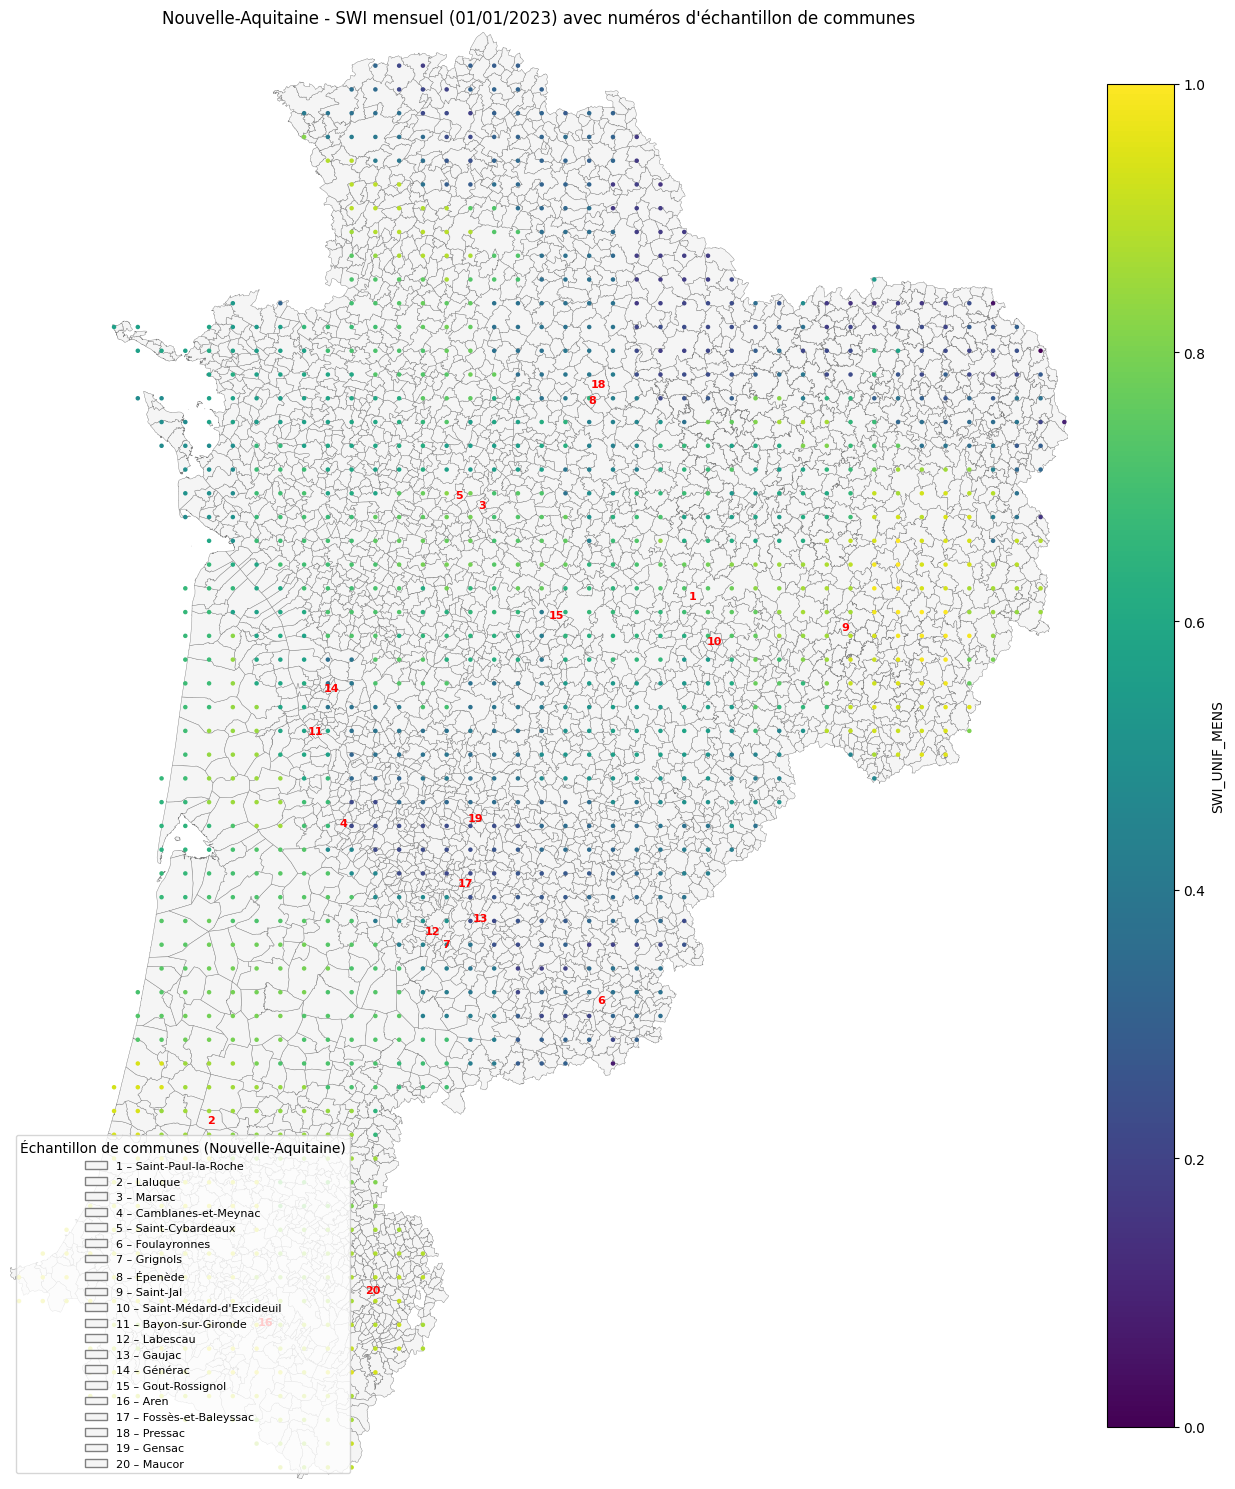

In [48]:


# Communes Nouvelle-Aquitaine dans le bon CRS
communes_na = communes[
    communes["code_insee_de_la_region"] == "75"   # Nouvelle-Aquitaine
].to_crs(gdf_join_argile.crs)

# Échantillon de communes NA
ech_communes_NA = communes_na.sample(20, random_state=0).copy()
ech_communes_NA["ID_ECH"] = range(1, len(ech_communes_NA) + 1)

# Données maille NA pour une date donnée
na_data = gdf_join_argile[
    (gdf_join_argile["REGION"] == "Nouvelle-Aquitaine") &
    (gdf_join_argile["DATE"] == "2023-01-01")
]

fig, ax = plt.subplots(figsize=(20, 15))

# Fond communes NA
communes_na.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="grey",
    linewidth=0.3
)

# Points maille SWI
points = na_data.plot(
    column="SWI_UNIF_MENS",
    ax=ax,
    cmap="viridis",
    markersize=5,
    legend=False
)

# Colorbar
cbar = plt.colorbar(points.collections[0], ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("SWI_UNIF_MENS")

# Numéros sur la carte pour l’échantillon
ech_communes_NA["centroid"] = ech_communes_NA.geometry.centroid
for x, y, num in zip(
    ech_communes_NA["centroid"].x,
    ech_communes_NA["centroid"].y,
    ech_communes_NA["ID_ECH"]
):
    ax.text(
        x, y, str(num),
        fontsize=8,
        ha="center",
        va="center",
        color="red",
        fontweight="bold"
    )

# Légende numéro ↔ nom de commune
legend_patches = []
for _, row in ech_communes_NA.iterrows():
    label = f"{row['ID_ECH']} – {row['nom_officiel']}"
    patch = mpatches.Patch(
        facecolor="whitesmoke",
        edgecolor="grey",
        label=label
    )
    legend_patches.append(patch)

ax.legend(
    handles=legend_patches,
    title="Échantillon de communes (Nouvelle-Aquitaine)",
    loc="lower left",
    fontsize=8,
    frameon=True
)

# Zoom sur NA
ax.set_xlim(communes_na.total_bounds[0], communes_na.total_bounds[2])
ax.set_ylim(communes_na.total_bounds[1], communes_na.total_bounds[3])

ax.set_title("Nouvelle-Aquitaine - SWI mensuel (01/01/2023) avec numéros d'échantillon de communes")
ax.set_axis_off()
plt.tight_layout()
plt.show()
